In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('KaggleV2-May-2016.csv')

# First look
df.head()import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=sms_noshow.index, y=sms_noshow.values, palette='Blues_d')
plt.xticks([0, 1], ['No SMS', 'SMS Received'])
plt.title('No-Show Rate by SMS Reminder')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('SMS Received')
plt.tight_layout()
plt.savefig('visuals/sms_noshow.png')
plt.show()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [3]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [4]:
# Check for missing values
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [5]:
# Fix date columns
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Convert No-show to 1/0
df['No-show'] = df['No-show'].map({'Yes': 1, 'No': 0})

# Create a new column: days between scheduling and appointment
df['DaysWaiting'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Verify
df[['ScheduledDay', 'AppointmentDay', 'DaysWaiting', 'No-show']].head()

,ScheduledDay,AppointmentDay,DaysWaiting,No-show
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,-1,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,-1,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,-1,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,-1,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,-1,0


In [6]:
# Strip time, keep just the date
df['ScheduledDay'] = df['ScheduledDay'].dt.date
df['AppointmentDay'] = df['AppointmentDay'].dt.date

# Recalculate DaysWaiting
df['DaysWaiting'] = (pd.to_datetime(df['AppointmentDay']) - pd.to_datetime(df['ScheduledDay'])).dt.days

# Verify
df[['ScheduledDay', 'AppointmentDay', 'DaysWaiting', 'No-show']].head()

,ScheduledDay,AppointmentDay,DaysWaiting,No-show
0,2016-04-29,2016-04-29,0,0
1,2016-04-29,2016-04-29,0,0
2,2016-04-29,2016-04-29,0,0
3,2016-04-29,2016-04-29,0,0
4,2016-04-29,2016-04-29,0,0


In [7]:
# Check for any negative DaysWaiting
print(df[df['DaysWaiting'] < 0].shape[0], "negative values found")

# Also check overall no-show rate
no_show_rate = df['No-show'].mean() * 100
print(f"Overall no-show rate: {no_show_rate:.1f}%")

5 negative values found
Overall no-show rate: 20.2%


In [8]:
# Drop negative DaysWaiting rows
df = df[df['DaysWaiting'] >= 0]

# Confirm
print(f"Rows remaining: {df.shape[0]}")
print(f"No-show rate: {df['No-show'].mean() * 100:.1f}%")

Rows remaining: 110522
No-show rate: 20.2%


In [9]:
sms_noshow = df.groupby('SMS_received')['No-show'].mean() * 100
print(sms_noshow)

SMS_received
0    16.697761
1    27.574545
Name: No-show, dtype: float64


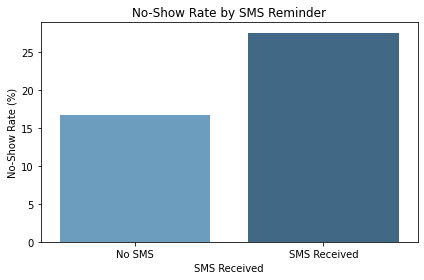

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x=sms_noshow.index, y=sms_noshow.values, palette='Blues_d')
plt.xticks([0, 1], ['No SMS', 'SMS Received'])
plt.title('No-Show Rate by SMS Reminder')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('SMS Received')
plt.tight_layout()
plt.savefig('visuals/sms_noshow.png')
plt.show()

In [11]:
import os
os.makedirs('visuals', exist_ok=True)

In [13]:
# Bin DaysWaiting into groups
bins = [0, 1, 7, 30, 90, df['DaysWaiting'].max()]
labels = ['Same Day', '1-7 Days', '8-30 Days', '31-90 Days', '90+ Days']
df['WaitGroup'] = pd.cut(df['DaysWaiting'], bins=bins, labels=labels, include_lowest=True)

# Calculate no-show rate per group
wait_noshow = df.groupby('WaitGroup', observed=True)['No-show'].mean() * 100
print(wait_noshow)

WaitGroup
Same Day       6.636056
1-7 Days      24.688566
8-30 Days     31.722003
31-90 Days    33.156185
90+ Days      25.806452
Name: No-show, dtype: float64


In [14]:
# Bin age into groups
age_bins = [0, 18, 35, 50, 65, df['Age'].max()]
age_labels = ['0-18', '19-35', '36-50', '51-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

# Calculate no-show rate per age group
age_noshow = df.groupby('AgeGroup', observed=True)['No-show'].mean() * 100
print(age_noshow)

AgeGroup
0-18     21.985103
19-35    23.828465
36-50    20.322187
51-65    16.549137
65+      15.526316
Name: No-show, dtype: float64


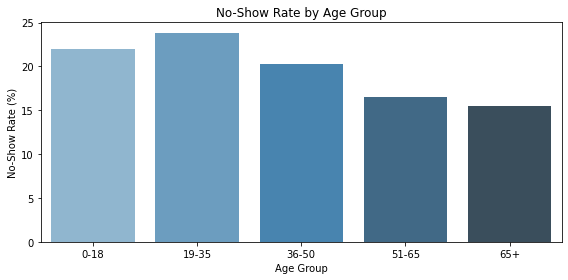

In [15]:
plt.figure(figsize=(8,4))
sns.barplot(x=age_noshow.index, y=age_noshow.values, palette='Blues_d')
plt.title('No-Show Rate by Age Group')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Age Group')
plt.tight_layout()
plt.savefig('visuals/age_noshow.png')
plt.show()

In [16]:
# No-show rate by chronic condition
conditions = ['Hipertension', 'Diabetes', 'Alcoholism']
condition_noshow = {c: df.groupby(c)['No-show'].mean() * 100 for c in conditions}

for condition, rates in condition_noshow.items():
    print(f"{condition}:")
    print(rates)
    print()

Hipertension:
Hipertension
0    20.899223
1    17.301959
Name: No-show, dtype: float64

Diabetes:
Diabetes
0    20.358943
1    18.003273
Name: No-show, dtype: float64

Alcoholism:
Alcoholism
0    20.190926
1    20.148810
Name: No-show, dtype: float64



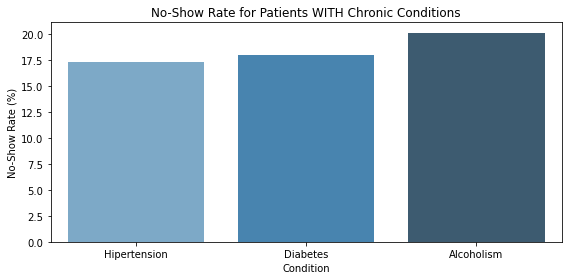

In [17]:
plt.figure(figsize=(8,4))
no_show_rates = [condition_noshow['Hipertension'][1], 
                 condition_noshow['Diabetes'][1], 
                 condition_noshow['Alcoholism'][1]]

sns.barplot(x=conditions, y=no_show_rates, palette='Blues_d')
plt.title('No-Show Rate for Patients WITH Chronic Conditions')
plt.ylabel('No-Show Rate (%)')
plt.xlabel('Condition')
plt.tight_layout()
plt.savefig('visuals/condition_noshow.png')
plt.show()

In [18]:
# No-show rate by neighbourhood (top 10 worst)
neighbourhood_noshow = df.groupby('Neighbourhood')['No-show'].mean() * 100
top10_noshow = neighbourhood_noshow.sort_values(ascending=False).head(10)
print(top10_noshow)

Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    100.000000
SANTOS DUMONT                   28.918495
SANTA CECÍLIA                   27.455357
SANTA CLARA                     26.482213
ITARARÉ                         26.266363
JESUS DE NAZARETH               24.395373
HORTO                           24.000000
ILHA DO PRÍNCIPE                23.477493
CARATOÍRA                       23.040936
ANDORINHAS                      23.032714
Name: No-show, dtype: float64


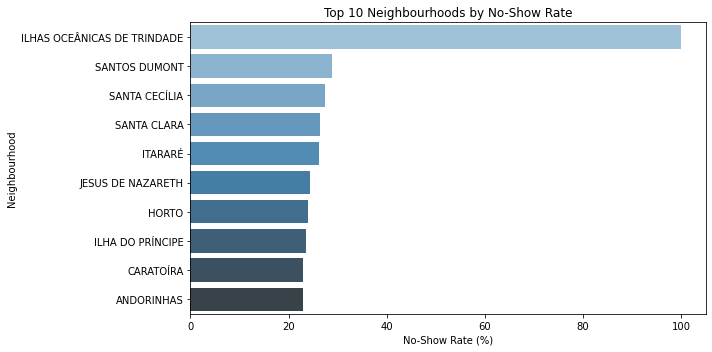

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(x=top10_noshow.values, y=top10_noshow.index, palette='Blues_d')
plt.title('Top 10 Neighbourhoods by No-Show Rate')
plt.xlabel('No-Show Rate (%)')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.savefig('visuals/neighbourhood_noshow.png')
plt.show()

In [20]:
print("=" * 50)
print("KEY FINDINGS - Healthcare No-Show Analysis")
print("=" * 50)
print(f"\n1. Overall no-show rate: 20.2%")
print(f"\n2. SMS reminders: patients who got SMS had HIGHER")
print(f"   no-show rates (27.6% vs 16.7%) - likely sent")
print(f"   to high-risk long-wait patients")
print(f"\n3. Longer wait = more no-shows. Same-day: 6.6%")
print(f"   vs 31-90 days: 33.2%")
print(f"\n4. Young adults (19-35) no-show most at 23.8%")
print(f"\n5. Chronic condition patients show up more:")
print(f"   Hypertension: 17.3%, Diabetes: 18.0%")
print(f"\n6. High-risk neighbourhoods: Santos Dumont,")
print(f"   Santa Cecilia, Santa Clara")
print("=" * 50)

KEY FINDINGS - Healthcare No-Show Analysis

1. Overall no-show rate: 20.2%

2. SMS reminders: patients who got SMS had HIGHER
   no-show rates (27.6% vs 16.7%) - likely sent
   to high-risk long-wait patients

3. Longer wait = more no-shows. Same-day: 6.6%
   vs 31-90 days: 33.2%

4. Young adults (19-35) no-show most at 23.8%

5. Chronic condition patients show up more:
   Hypertension: 17.3%, Diabetes: 18.0%

6. High-risk neighbourhoods: Santos Dumont,
   Santa Cecilia, Santa Clara
